# **Clustering**

**Theoretical Questions**

**1. What is unsupervised learning in the context of machine learning?**
- Unsupervised learning involves training models on data that has no labeled output. The goal is to find hidden patterns or intrinsic structures in the input data. Clustering is a common technique used in unsupervised learning.

**2. How does K-Means clustering algorithm work?**
- Select K initial cluster centroids randomly or using K-Means++.
- Assign each point to the nearest centroid.
- Update centroids as the mean of all assigned points.
- Repeat until convergence (centroids don’t change).

**3. Explain the concept of a dendrogram in hierarchical clustering?**
- A dendrogram is a tree-like diagram showing the sequence of merges or splits in hierarchical clustering. The height of each merge represents the distance between clusters.

**4. What is the main difference between K-Means and Hierarchical Clustering?**
- K-Means partitions data into K clusters by minimizing within-cluster variance. Hierarchical clustering builds a tree of clusters either by merging (agglomerative) or splitting (divisive) steps, without needing to predefine the number of clusters.

**5. What are the advantages of DBSCAN over K-Means?**
- Can detect clusters of arbitrary shape.
- No need to predefine the number of clusters.
- Identifies noise points.
- Handles varying density better than K-Means.

**6. When would you use Silhouette Score in clustering?**
- To evaluate how well each data point fits within its cluster. It ranges from -1 to 1; higher scores indicate better-defined clusters.

**7. What are the limitations of Hierarchical Clustering?**
- Computationally expensive (not scalable for large datasets).
- Once merged or split, clusters cannot be undone.
- Sensitive to noise and outliers.

**8. Why is feature scaling important in clustering algorithms like K-Means?**
- Because K-Means relies on Euclidean distance, and features with larger scales can dominate the clustering process, leading to biased results.

**9. How does DBSCAN identify noise points?**
- Points that do not have enough neighbors within a specified distance (eps) are marked as noise.

**10. Define inertia in the context of K-Means.**
- Inertia is the sum of squared distances between data points and their respective cluster centroids. Lower inertia indicates tighter clusters.

**11. What is the elbow method in K-Means clustering?**
- A graphical method to determine the optimal number of clusters by plotting inertia vs. number of clusters. The "elbow" point is the best K.

**12. Describe the concept of "density" in DBSCAN.**
- Density is defined by the number of points within a radius eps around a point. If it exceeds min_samples, the point is considered a core point.

**13. Can hierarchical clustering be used on categorical data?**
- Yes, but it requires an appropriate distance measure like Hamming distance or the use of Gower distance for mixed data types.

**14. What does a negative Silhouette Score indicate?**
- It means the point may have been assigned to the wrong cluster as it's closer to points in a different cluster.

**15. Explain the term "linkage criteria" in hierarchical clustering.**
- Linkage criteria define how the distance between clusters is computed:
1. Single: minimum distance.
2. Complete: maximum distance.
3. Average: mean distance.

**16. Why might K-Means clustering perform poorly on data with varying cluster sizes or densities?**
- Because K-Means assumes clusters are spherical and equally sized. It performs poorly with non-globular or uneven density clusters.

**17.  What are the core parameters in DBSCAN, and how do they influence clustering?**
- Density is defined by the number of points within a radius eps around a point. If it exceeds min_samples, the point is considered a core point.
- eps: maximum distance to consider a neighbor.
- min_samples: minimum points to form a dense region.

They determine cluster formation and noise detection.

**18. How does K-Means++ improve upon standard K-Means initialization?**
- It chooses initial centroids in a way that spreads them out, reducing chances of poor convergence and improving accuracy.

**19. What is agglomerative clustering?**
- It is a bottom-up hierarchical method that starts with each point as a separate cluster and merges them iteratively based on linkage criteria.

**20. What makes Silhouette Score a better metric than just inertia for model evaluation?**
- Silhouette Score considers both intra-cluster cohesion and inter-cluster separation, giving a better sense of cluster quality than just inertia, which only reflects within-cluster tightness.

**Practical Questions**

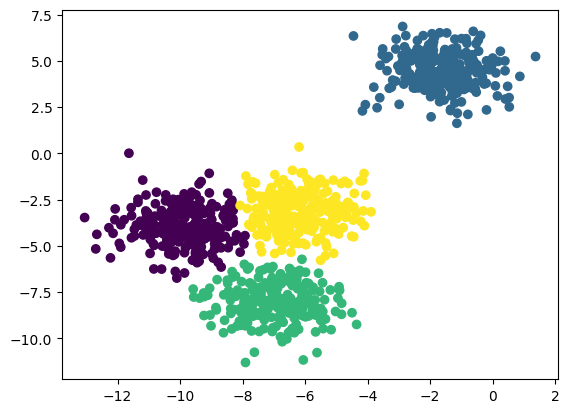

In [1]:
# 1.Generate synthetic data with 4 centers using make_blobs and apply K-Means clustering. Visualize using a scatter plot.
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
x,y = make_blobs(n_samples=1000, centers=4, random_state=1)
kmean = KMeans(n_clusters=4)
kmean.fit(x)
plt.scatter(x[:,0],x[:,1],c=kmean.labels_)
plt.show()

In [2]:
# 2. Load the Iris dataset and use Agglomerative Clustering to group the data into 3 clusters. Display the first 10 predicted labels.
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
iris = load_iris()
x = iris.data
y = iris.target
model = AgglomerativeClustering(n_clusters=3)
model.fit(x)
print(model.labels_[:10])

[1 1 1 1 1 1 1 1 1 1]


/tmp/ipython-input-14-1115906777.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(unique_labels))


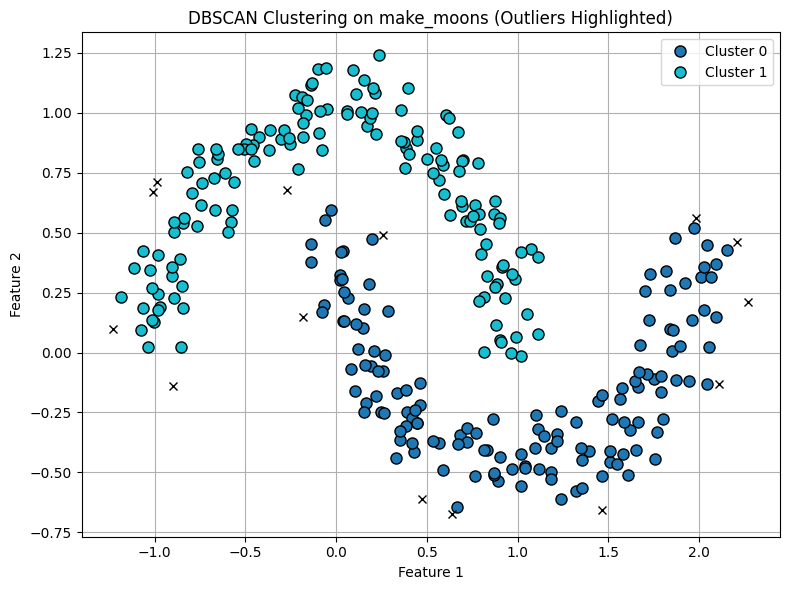

In [14]:
# 3.Generate synthetic data using make_moons and apply DBSCAN. Highlight outliers in the plot.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

X, _ = make_moons(n_samples=300, noise=0.1, random_state=42)

dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True
unique_labels = set(labels)

plt.figure(figsize=(8, 6))
colors = plt.cm.get_cmap("tab10", len(unique_labels))

for k in unique_labels:
    class_member_mask = (labels == k)

    # Core points
    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=colors(k), markeredgecolor='k', markersize=8, label=f'Cluster {k}' if k != -1 else 'Noise')

    # Border points
    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'x', markerfacecolor=colors(k), markeredgecolor='k', markersize=6)

plt.title("DBSCAN Clustering on make_moons (Outliers Highlighted)")
plt.legend()
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.tight_layout()
plt.show()


In [16]:
# 4.Load the Wine dataset and apply K-Means clustering after standardizing the features. Print the size of each cluster.
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np
wine = load_wine()
X = wine.data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# Print the size of each cluster
unique, counts = np.unique(labels, return_counts=True)
for cluster, size in zip(unique, counts):
    print(f"Cluster {cluster}: {size} samples")

Cluster 0: 65 samples
Cluster 1: 51 samples
Cluster 2: 62 samples


/tmp/ipython-input-17-1016977332.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(unique_labels))


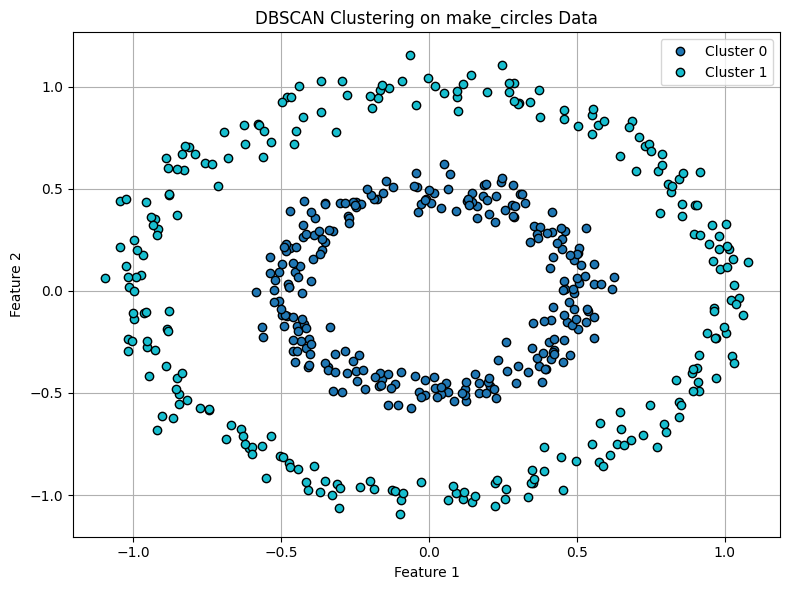

In [17]:
# 5.Use make_circles to generate synthetic data and cluster it using DBSCAN. Plot the result.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN

# Generate synthetic circular data
X, _ = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)

dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

# Plot the result
plt.figure(figsize=(8, 6))
unique_labels = set(labels)
colors = plt.cm.get_cmap("tab10", len(unique_labels))

for k in unique_labels:
    class_member_mask = (labels == k)
    xy = X[class_member_mask]

    if k == -1:
        # Noise
        plt.plot(xy[:, 0], xy[:, 1], 'x', color='black', label='Noise')
    else:
        plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=colors(k), markeredgecolor='k', markersize=6, label=f'Cluster {k}')

plt.title("DBSCAN Clustering on make_circles Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [19]:
# 6. Load the Breast Cancer dataset, apply MinMaxScaler, and use K-Means with 2 clusters. Output the cluster centroids.
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import numpy as np
cancer = load_breast_cancer()
X = cancer.data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=2)
labels = kmeans.fit_predict(X_scaled)
print("Cluster centroids:")
print(kmeans.cluster_centers_)

Cluster centroids:
[[0.50483563 0.39560329 0.50578661 0.36376576 0.46988732 0.42226302
  0.41838662 0.46928035 0.45899738 0.29945886 0.19093085 0.19112073
  0.17903433 0.13086432 0.18017962 0.25890126 0.12542475 0.30942779
  0.190072   0.13266975 0.48047448 0.45107371 0.4655302  0.31460597
  0.49868817 0.36391461 0.39027292 0.65827197 0.33752296 0.26041387]
 [0.25535358 0.28833455 0.24696416 0.14388369 0.35743076 0.18019471
  0.10344776 0.1306603  0.34011829 0.25591606 0.06427485 0.18843043
  0.05975663 0.02870108 0.18158628 0.13242941 0.05821528 0.18069336
  0.17221057 0.08403996 0.2052406  0.32069002 0.19242138 0.09943446
  0.3571115  0.14873935 0.13142287 0.26231363 0.22639412 0.15437354]]


/tmp/ipython-input-20-3082445830.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(unique_labels))


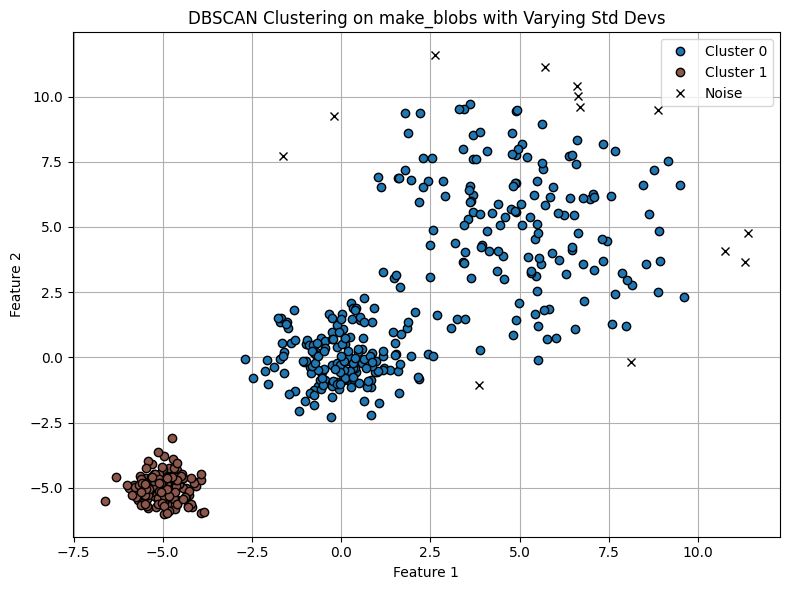

In [20]:
# 7. Generate synthetic data using make_blobs with varying cluster standard deviations and cluster with DBSCAN.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN

X, _ = make_blobs(n_samples=500,
                  centers=[(-5, -5), (0, 0), (5, 5)],
                  cluster_std=[0.5, 1.0, 2.5],  # Different stds
                  random_state=42)

dbscan = DBSCAN(eps=1.2, min_samples=5)
labels = dbscan.fit_predict(X)

#Plot the result
plt.figure(figsize=(8, 6))
unique_labels = set(labels)
colors = plt.cm.get_cmap("tab10", len(unique_labels))

for k in unique_labels:
    class_member_mask = (labels == k)
    xy = X[class_member_mask]

    if k == -1:
        # Noise points
        plt.plot(xy[:, 0], xy[:, 1], 'x', color='black', label='Noise')
    else:
        plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=colors(k), markeredgecolor='k', markersize=6, label=f'Cluster {k}')

plt.title("DBSCAN Clustering on make_blobs with Varying Std Devs")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

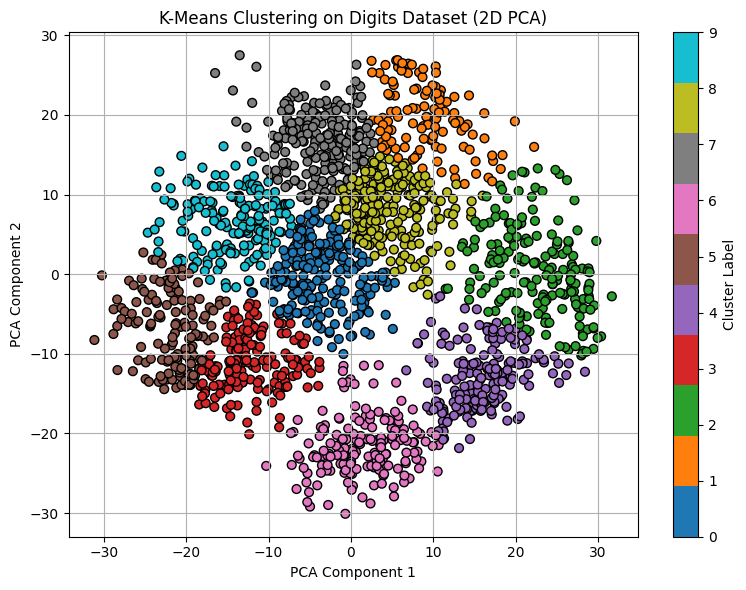

In [24]:
# 8.Load the Digits dataset, reduce it to 2D using PCA, and visualize clusters from K-Means.
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
digits = load_digits()
X = digits.data

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_pca)

# Plot the clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', edgecolor='k', s=40)
plt.title("K-Means Clustering on Digits Dataset (2D PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label="Cluster Label")
plt.grid(True)
plt.tight_layout()
plt.show()

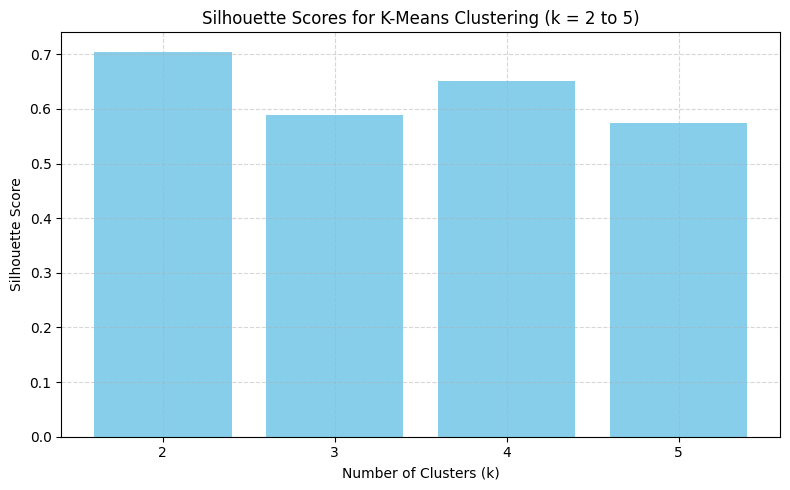

In [27]:
# 9. Create synthetic data using make_blobs and evaluate silhouette scores for k = 2 to 5. Display as a bar chart.
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X, _ = make_blobs(n_samples=500, centers=4, cluster_std=1.0, random_state=1)

k_values = range(2, 6)
silhouette_scores = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

# Step 3: Plot silhouette scores as a bar chart
plt.figure(figsize=(8, 5))
plt.bar(k_values, silhouette_scores, color='skyblue')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for K-Means Clustering (k = 2 to 5)")
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


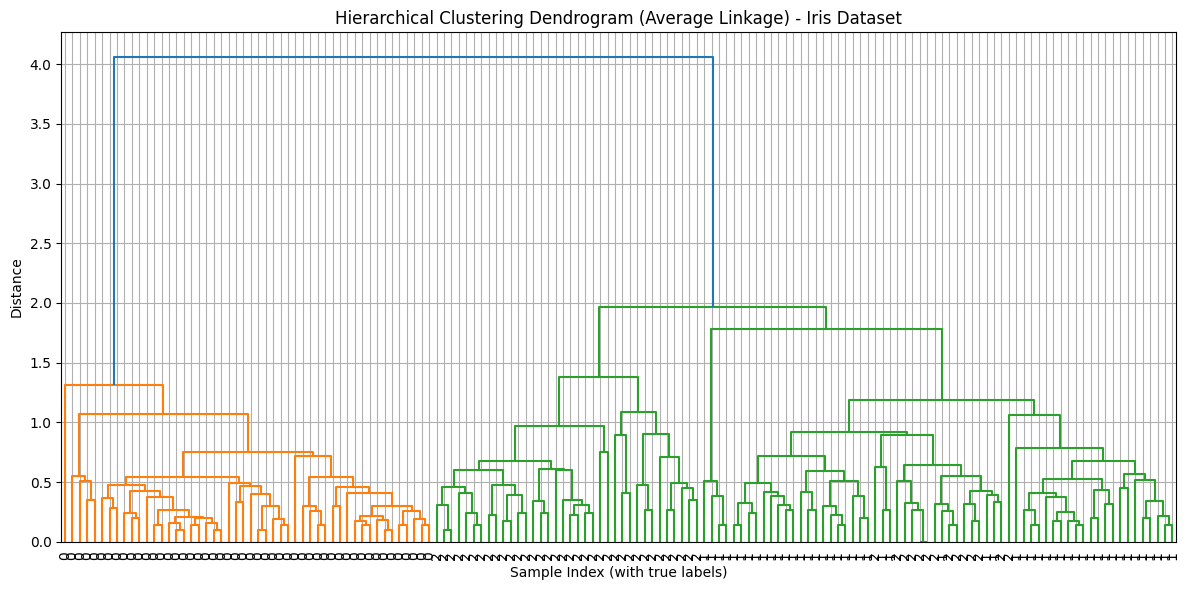

In [30]:
# 10. Load the Iris dataset and use hierarchical clustering to group data. Plot a dendrogram with average linkage.
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import dendrogram, linkage
iris = load_iris()
X = iris.data

linkage_matrix = linkage(X, method='average')

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, labels=iris.target, leaf_rotation=90, leaf_font_size=10)
plt.title("Hierarchical Clustering Dendrogram (Average Linkage) - Iris Dataset")
plt.xlabel("Sample Index (with true labels)")
plt.ylabel("Distance")
plt.grid(True)
plt.tight_layout()
plt.show()


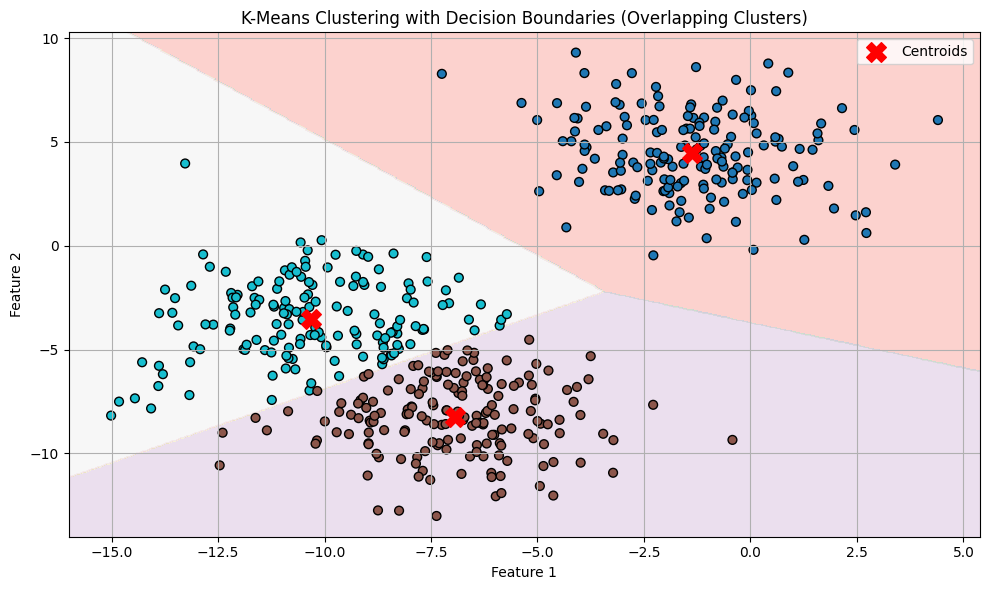

In [31]:
# 11.Generate synthetic data with overlapping clusters using make_blobs, then apply K-Means and visualize with decision boundaries.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=2.0, random_state=1)

kmeans = KMeans(n_clusters=3, n_init=10)
kmeans.fit(X)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

h = 0.05
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundaries and clusters
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, cmap='Pastel1', alpha=0.6)

# Plot actual data points
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', edgecolor='k', s=40)

# Plot centroids
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')

plt.title("K-Means Clustering with Decision Boundaries (Overlapping Clusters)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/tmp/ipython-input-32-1173495155.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(unique_labels))


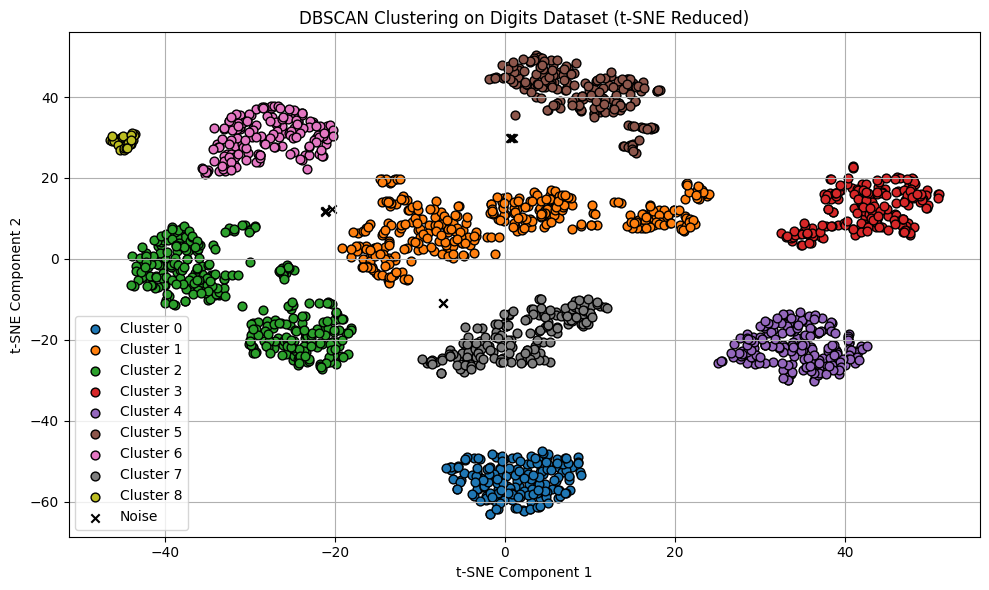

In [32]:
# 12. Load the Digits dataset and apply DBSCAN after reducing dimensions with t-SNE. Visualize the results.
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN

digits = load_digits()
X = digits.data

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X)

dbscan = DBSCAN(eps=5, min_samples=5)
labels = dbscan.fit_predict(X_tsne)

plt.figure(figsize=(10, 6))
unique_labels = set(labels)
colors = plt.cm.get_cmap("tab10", len(unique_labels))

for k in unique_labels:
    mask = (labels == k)
    if k == -1:
        # Noise
        plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c='black', marker='x', label='Noise')
    else:
        plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=f'Cluster {k}', s=40, edgecolor='k')

plt.title("DBSCAN Clustering on Digits Dataset (t-SNE Reduced)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


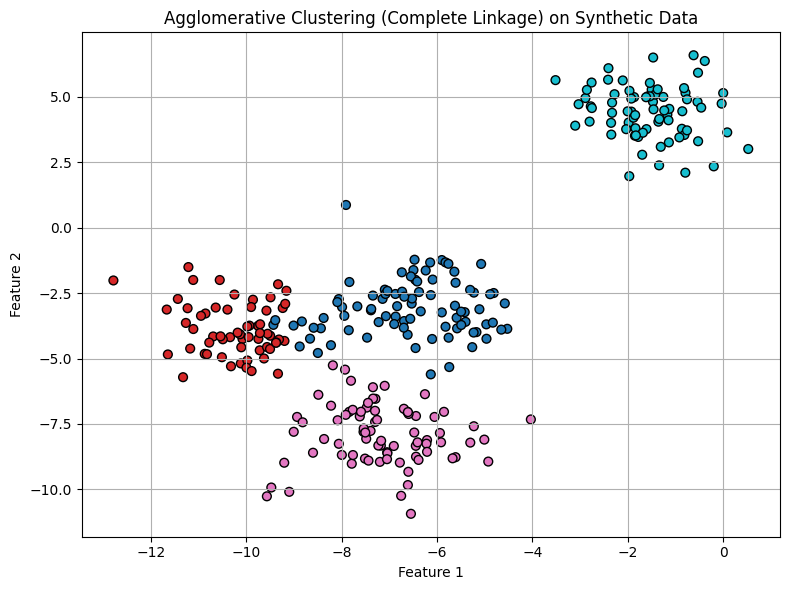

In [33]:
# 13.Generate synthetic data using make_blobs and apply Agglomerative Clustering with complete linkage. Plot the result.
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering

X, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=1)

agglo = AgglomerativeClustering(n_clusters=4, linkage='complete')
labels = agglo.fit_predict(X)

# Plot the clusters
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', edgecolor='k', s=40)
plt.title("Agglomerative Clustering (Complete Linkage) on Synthetic Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.tight_layout()
plt.show()


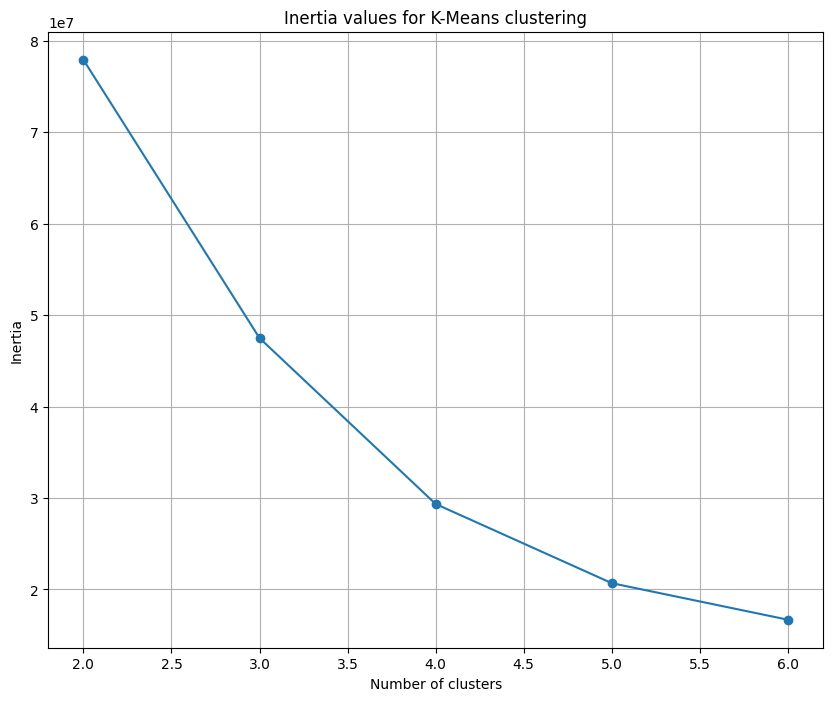

In [36]:
# 14.Load the Breast Cancer dataset and compare inertia values for K = 2 to 6 using K-Means. Show results in a line plot.
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans

cancer = load_breast_cancer()
X = cancer.data
inertia = []
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(10,8))
plt.plot(range(2, 7), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Inertia values for K-Means clustering')
plt.grid(True)
plt.show()

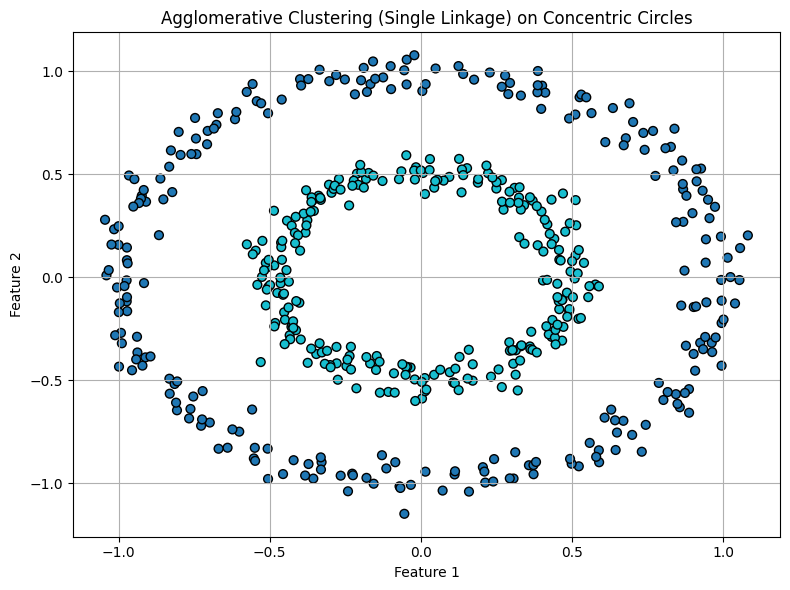

In [35]:
# 15. Generate synthetic concentric circles using make_circles and cluster using Agglomerative Clustering with single linkage.
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import AgglomerativeClustering

X, _ = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=1)

agglo = AgglomerativeClustering(n_clusters=2, linkage='single')
labels = agglo.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', edgecolor='k', s=40)
plt.title("Agglomerative Clustering (Single Linkage) on Concentric Circles")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.tight_layout()
plt.show()


In [37]:
# 16. Use the Wine dataset, apply DBSCAN after scaling the data, and count the number of clusters (excluding noise).
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

wine = load_wine()
X = wine.data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

dbscan = DBSCAN(eps=1.2, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Number of clusters found (excluding noise): {n_clusters}")


Number of clusters found (excluding noise): 0


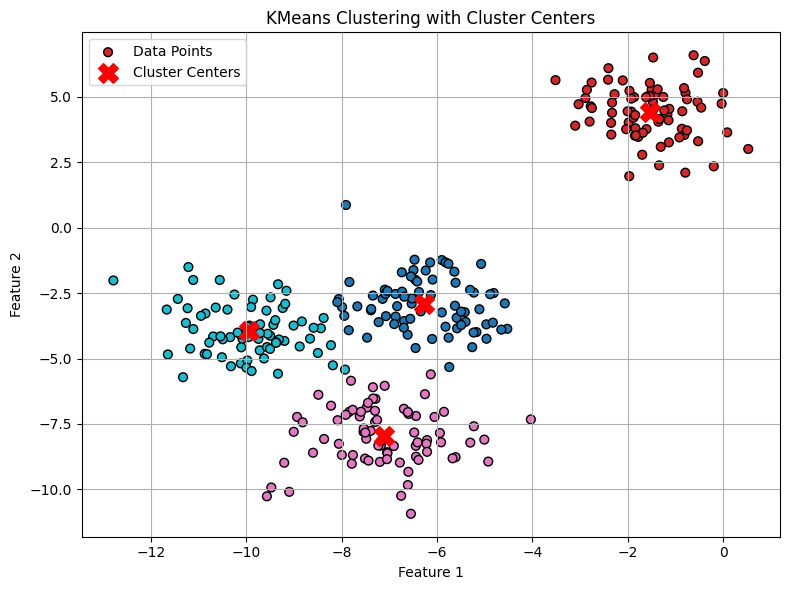

In [38]:
# 17.Generate synthetic data with make_blobs and apply KMeans. Then plot the cluster centers on top of the data points.
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=1)

kmeans = KMeans(n_clusters=4,n_init=10)
labels = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', edgecolor='k', s=40, label='Data Points')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Cluster Centers')

plt.title("KMeans Clustering with Cluster Centers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [39]:
# 18.Load the Iris dataset, cluster with DBSCAN, and print how many samples were identified as noise.
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

iris = load_iris()
X = iris.data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

dbscan = DBSCAN(eps=0.6, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

n_noise = np.sum(labels == -1)
print(f"Number of noise samples: {n_noise}")


Number of noise samples: 26


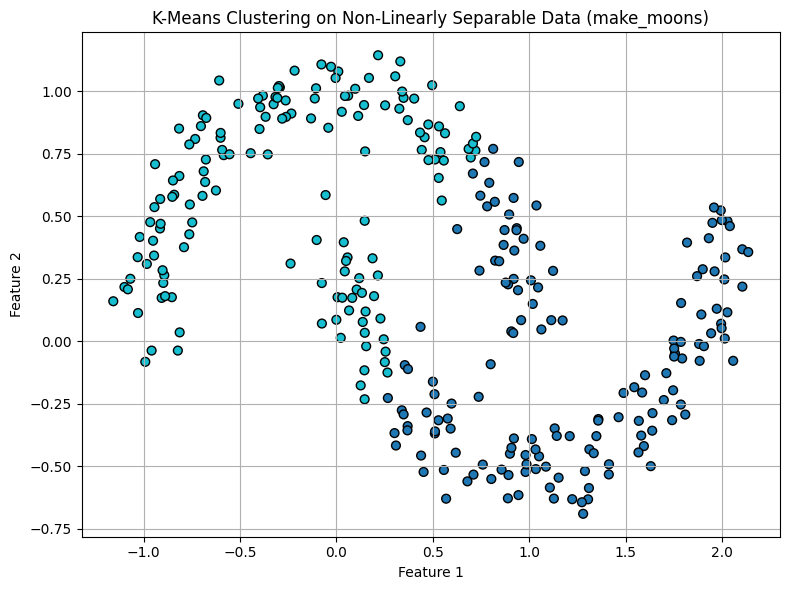

In [40]:
# 19.Generate synthetic non-linearly separable data using make_moons, apply K-Means, and visualize the clustering result.
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans

X, _ = make_moons(n_samples=300, noise=0.1, random_state=1)

kmeans = KMeans(n_clusters=2, n_init=10)
labels = kmeans.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', edgecolor='k', s=40)
plt.title("K-Means Clustering on Non-Linearly Separable Data (make_moons)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.tight_layout()
plt.show()


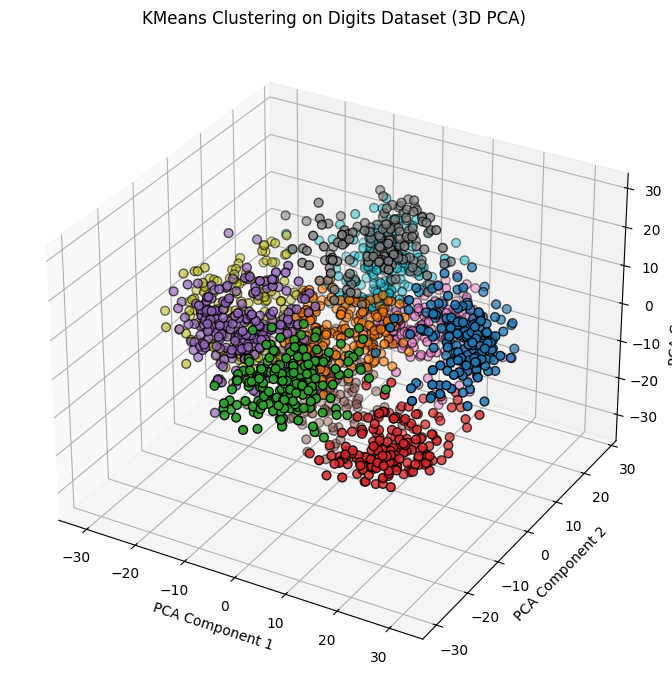

In [41]:
# 20. Load the Digits dataset, apply PCA to reduce to 3 components, then use KMeans and visualize with a 3D scatter plot.
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D  # Required for 3D plotting

digits = load_digits()
X = digits.data

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

kmeans = KMeans(n_clusters=10, n_init=10)
labels = kmeans.fit_predict(X_pca)

# 3D Scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
                     c=labels, cmap='tab10', edgecolor='k', s=40)

ax.set_title("KMeans Clustering on Digits Dataset (3D PCA)")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
plt.tight_layout()
plt.show()


In [42]:
# 21.Generate synthetic blobs with 5 centers and apply KMeans. Then use silhouette_score to evaluate the clustering.
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

x,y = make_blobs(n_samples=500, centers=5, cluster_std=1.0, random_state=1)

kmeans = KMeans(n_clusters=5, n_init=10)
labels = kmeans.fit_predict(x)

silhouette_avg = silhouette_score(x, labels)
print(f"Silhouette Score: {silhouette_avg}")


Silhouette Score: 0.5740089825824137


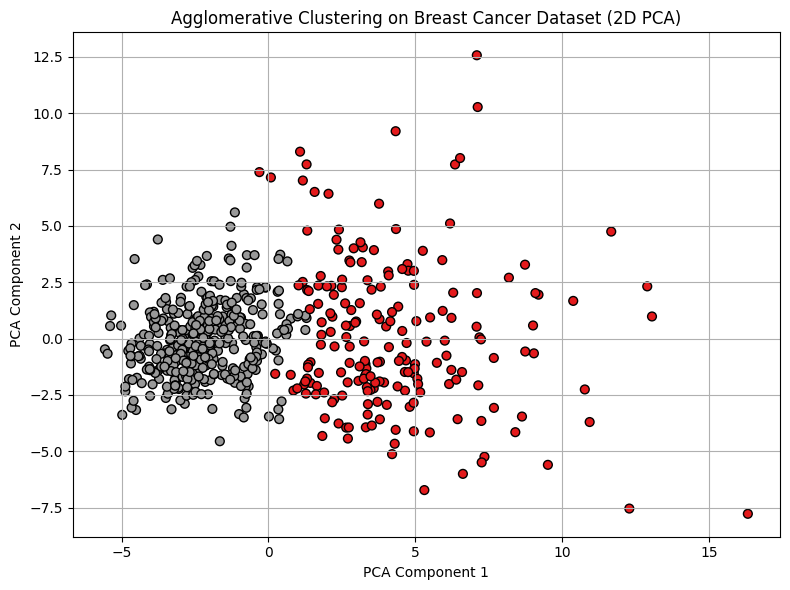

In [43]:
# 22.Load the Breast Cancer dataset, reduce dimensionality using PCA, and apply Agglomerative Clustering. Visualize in 2D.
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

data = load_breast_cancer()
X = data.data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

agglo = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels = agglo.fit_predict(X_pca)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='Set1', edgecolor='k', s=40)
plt.title("Agglomerative Clustering on Breast Cancer Dataset (2D PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()

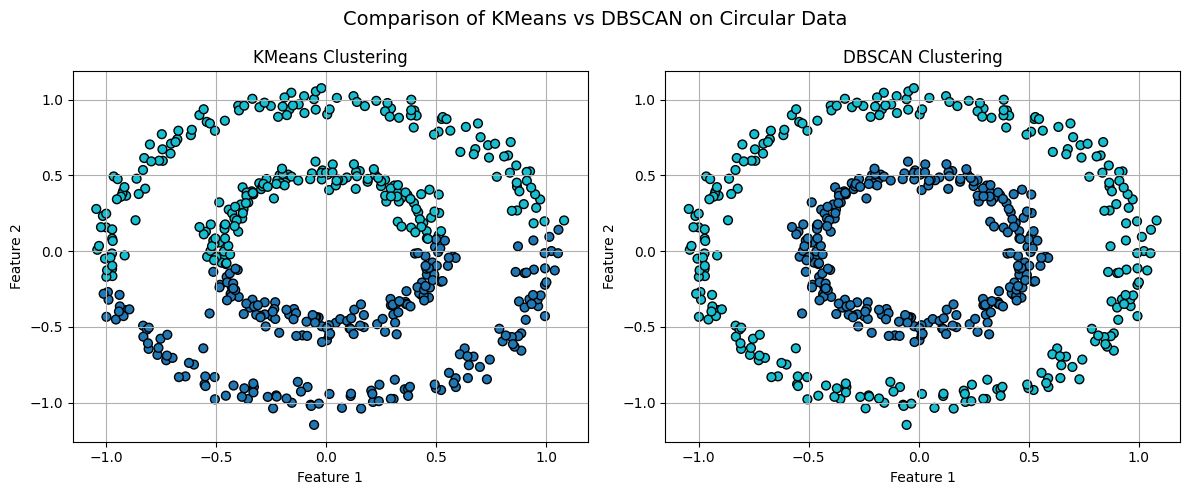

In [44]:
# 23.Generate noisy circular data using make_circles and visualize clustering results from KMeans and DBSCAN side-by-side.
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import KMeans, DBSCAN

X, _ = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=1)

kmeans = KMeans(n_clusters=2, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# KMeans result
axs[0].scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='tab10', edgecolor='k', s=40)
axs[0].set_title("KMeans Clustering")
axs[0].set_xlabel("Feature 1")
axs[0].set_ylabel("Feature 2")
axs[0].grid(True)

# DBSCAN result
axs[1].scatter(X[:, 0], X[:, 1], c=dbscan_labels, cmap='tab10', edgecolor='k', s=40)
axs[1].set_title("DBSCAN Clustering")
axs[1].set_xlabel("Feature 1")
axs[1].set_ylabel("Feature 2")
axs[1].grid(True)

plt.suptitle("Comparison of KMeans vs DBSCAN on Circular Data", fontsize=14)
plt.tight_layout()
plt.show()


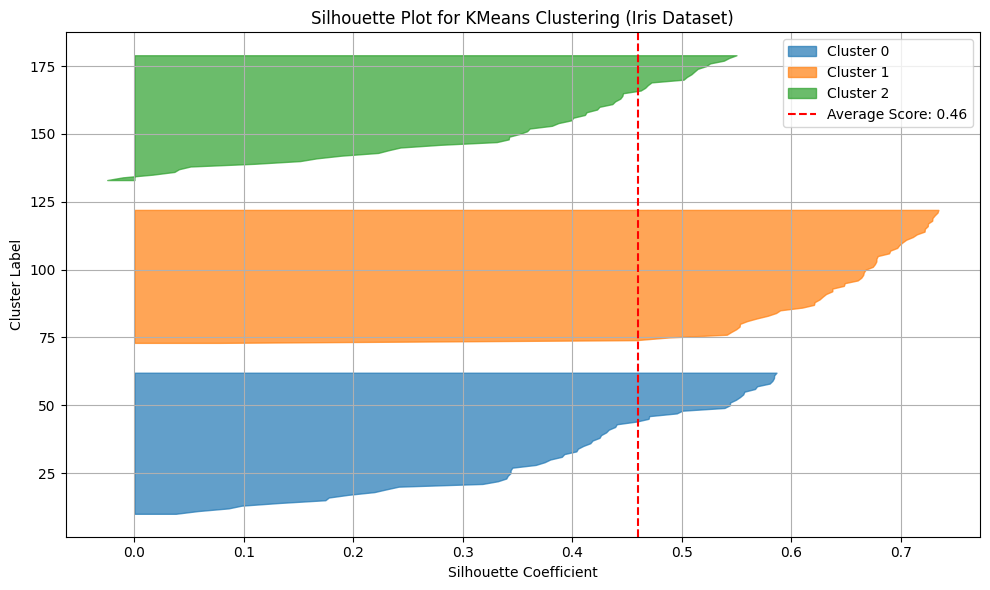

In [45]:
# 24.Load the Iris dataset and plot the Silhouette Coefficient for each sample after KMeans clustering.
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X = iris.data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

silhouette_vals = silhouette_samples(X_scaled, labels)

plt.figure(figsize=(10, 6))
y_lower = 10
for i in np.unique(labels):
    ith_cluster_silhouette_values = silhouette_vals[labels == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = plt.cm.tab10(i)
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7, label=f"Cluster {i}")
    y_lower = y_upper + 10  # 10 for spacing between clusters

# Plot average silhouette score
avg_score = silhouette_score(X_scaled, labels)
plt.axvline(avg_score, color="red", linestyle="--", label=f"Average Score: {avg_score:.2f}")

plt.title("Silhouette Plot for KMeans Clustering (Iris Dataset)")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Cluster Label")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

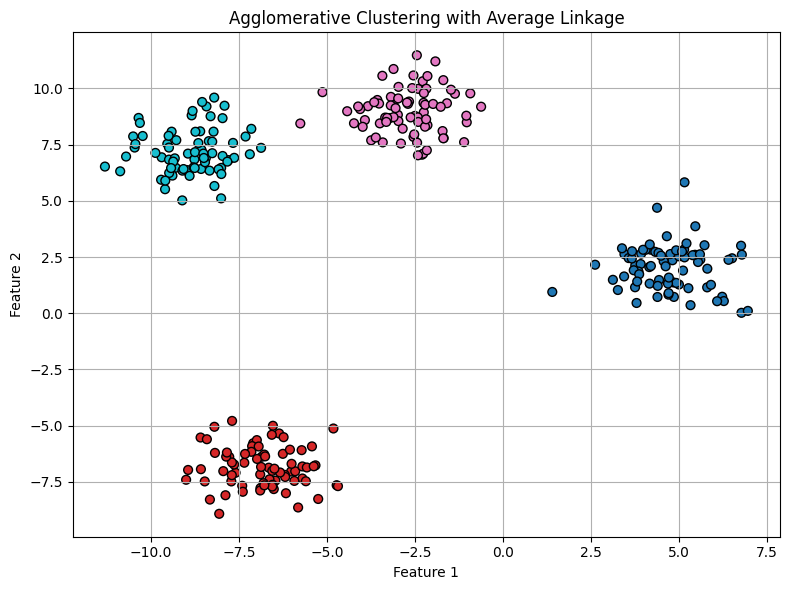

In [46]:
# 25.Generate synthetic data using make_blobs and apply Agglomerative Clustering with 'average' linkage.Visualize clusters.
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering

X, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=42)

agglo = AgglomerativeClustering(n_clusters=4, linkage='average')
labels = agglo.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', edgecolor='k', s=40)
plt.title("Agglomerative Clustering with Average Linkage")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.tight_layout()
plt.show()

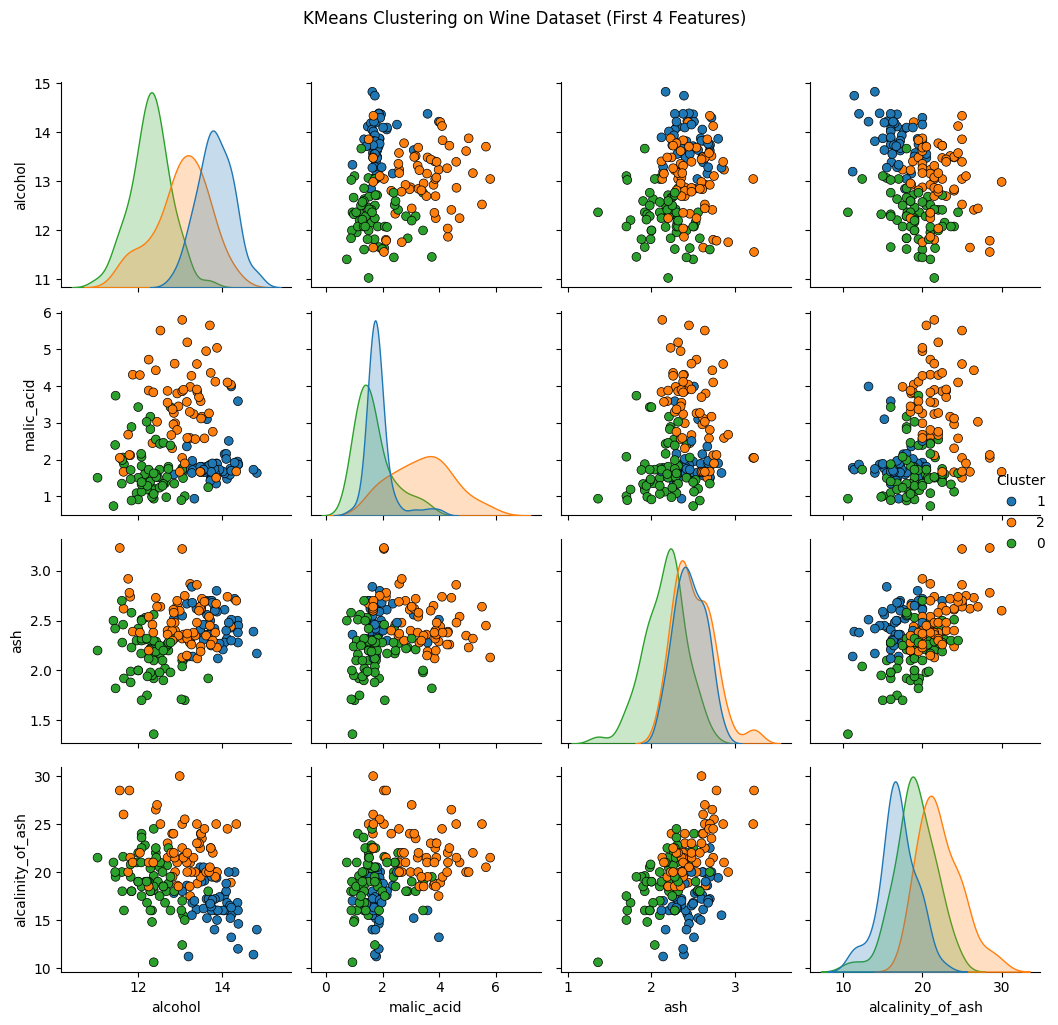

In [47]:
# 26.Load the Wine dataset, apply KMeans, and visualize the cluster assignments in a seaborn pairplot (first 4 features).
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

wine = load_wine()
X = wine.data[:, :4]  # Use only the first 4 features
feature_names = wine.feature_names[:4]

df = pd.DataFrame(X, columns=feature_names)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

df['Cluster'] = labels.astype(str)

# Plot pairplot
sns.pairplot(df, hue='Cluster', palette='tab10', diag_kind='kde', plot_kws={'edgecolor': 'k', 's': 40})
plt.suptitle("KMeans Clustering on Wine Dataset (First 4 Features)", y=1.02)
plt.tight_layout()
plt.show()


In [48]:
# 27.Generate noisy blobs using make_blobs and use DBSCAN to identify both clusters and noise points. Print the count.
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import numpy as np

X, _ = make_blobs(n_samples=500, centers=4, cluster_std=1.0, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

print(f"Number of clusters found (excluding noise): {n_clusters}")
print(f"Number of noise points: {n_noise}")

Number of clusters found (excluding noise): 3
Number of noise points: 0


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


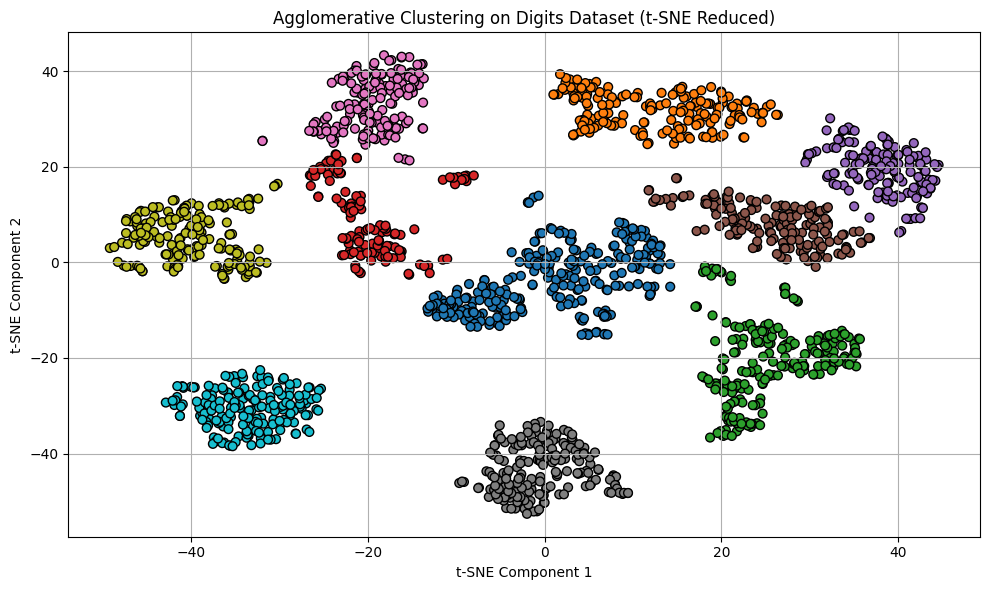

In [49]:
# 28.Load the Digits dataset, reduce dimensions using t-SNE, then apply Agglomerative Clustering and plot the clusters.
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X = digits.data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

tsne = TSNE(n_components=2, perplexity=30, random_state=1, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

agglo = AgglomerativeClustering(n_clusters=10, linkage='ward')
labels = agglo.fit_predict(X_tsne)

plt.figure(figsize=(10, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', edgecolor='k', s=40)
plt.title("Agglomerative Clustering on Digits Dataset (t-SNE Reduced)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()
